# Chiller Plant Data Generation

**Abriliam Consulting** — Industrial Energy Management

This notebook generates a synthetic 8-week chiller plant dataset simulating realistic central plant operations for a commercial building during summer cooling season (June–July 2025). The dataset serves as a controlled environment for diagnostic training — with **three hidden operational faults** embedded in the data.

### What's in the dataset
- **1,344 hourly observations** across 23 columns
- Weather drivers (outdoor air temperature, wet-bulb proxy)
- Occupancy-driven cooling loads (weekday/weekend patterns)
- Chilled water loop: supply/return temperatures, delta-T, flow rates
- Condenser water loop: supply/return temperatures, cooling tower approach
- Equipment power: chiller, tower fans, CHW pumps, CW pumps
- Derived KPIs: kW/ton (chiller and plant-level), pumping intensity

### Hidden faults (revealed later in the series)
1. **Low delta-T syndrome** — CHW temperature differential collapses mid-series, driving excessive pump energy
2. **Cooling tower degradation** — approach temperature drifts upward over the 8-week period
3. **Night-time fan control bias** — tower fans run harder than necessary during low-load overnight hours


In [ ]:
import matplotlib
matplotlib.use('Agg')

C:\Users\mikea\AppData\Local\Temp\ipykernel_20836\645578401.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range("2025-06-01", "2025-07-26 23:00:00", freq="H")


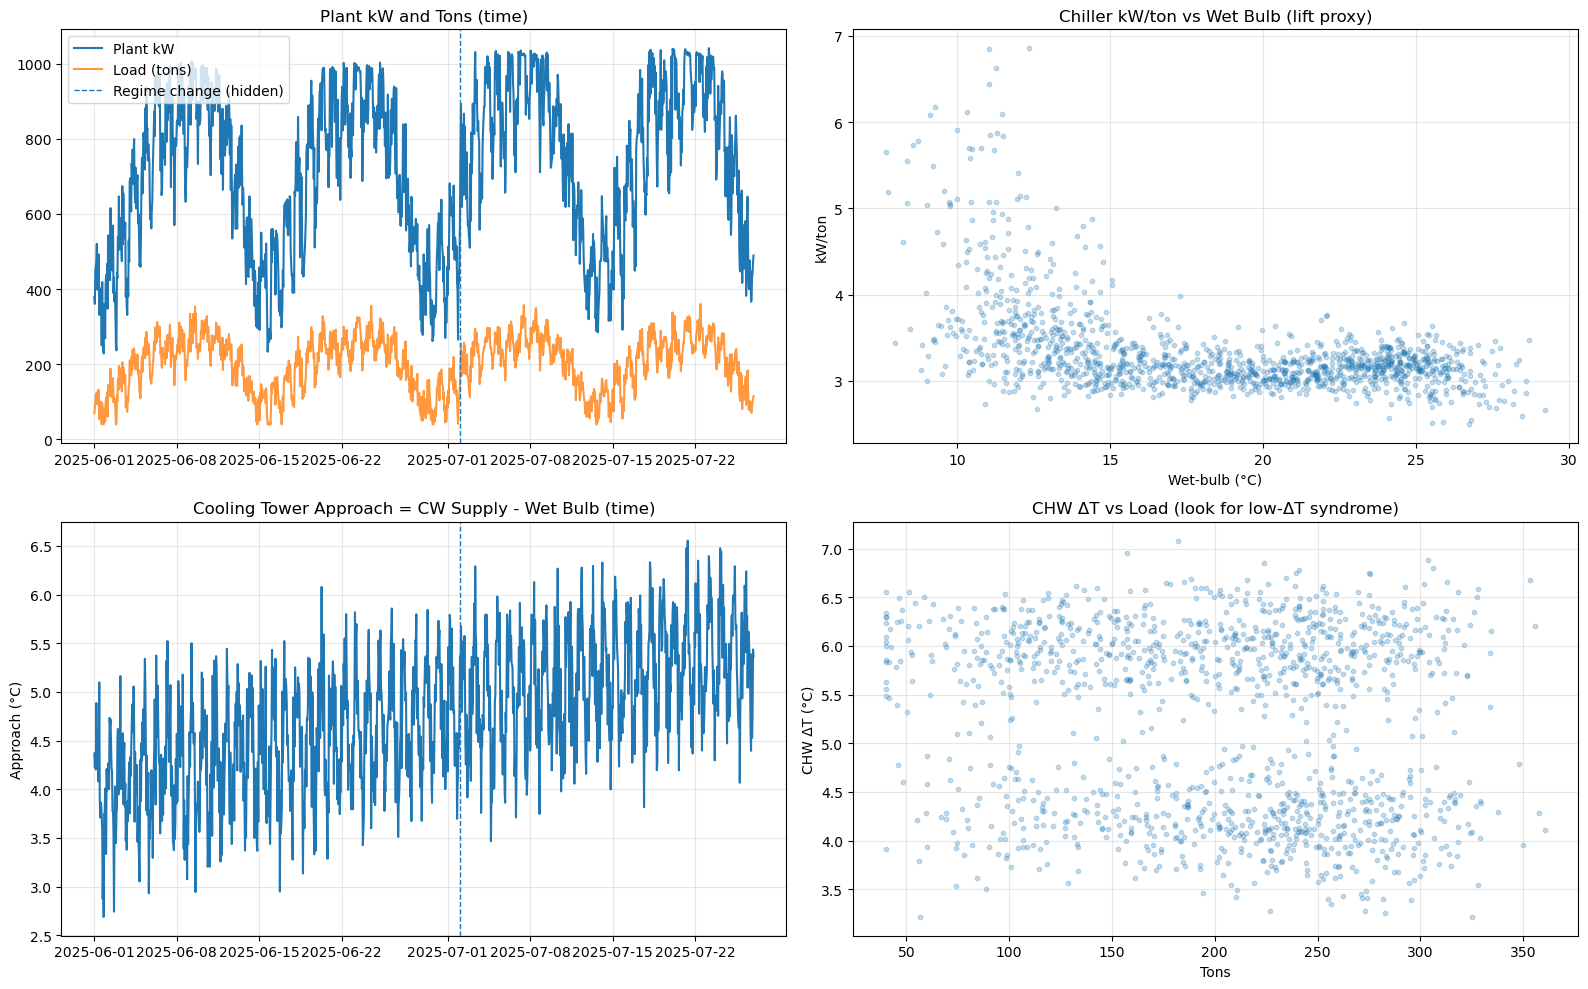

Dataset ready as `df` (hourly). Columns:
['oat_C', 'wb_C', 'occ', 'tons', 'chw_sup_C', 'chw_ret_C', 'chw_dT_C', 'chw_flow_m3h', 'cw_sup_C', 'cw_ret_C', 'cw_dT_C', 'cw_flow_m3h', 'approach_C', 'dp_kpa', 'chiller_kw', 'tower_fan_kw', 'chw_pump_kw', 'cw_pump_kw', 'plant_kw', 'kw_per_ton', 'plant_kw_per_ton', 'tower_fan_kw_per_ton', 'pumping_kw_per_ton']

Sample:


,oat_C,wb_C,occ,tons,chw_sup_C,chw_ret_C,chw_dT_C,chw_flow_m3h,cw_sup_C,cw_ret_C,...,dp_kpa,chiller_kw,tower_fan_kw,chw_pump_kw,cw_pump_kw,plant_kw,kw_per_ton,plant_kw_per_ton,tower_fan_kw_per_ton,pumping_kw_per_ton
2025-06-01 00:00:00,17.204135,14.419056,0.084295,69.111653,6.590836,12.583527,5.992692,34.235655,18.785822,23.063083,...,155.394522,337.166323,27.540604,9.158541,5.288851,379.154320,4.878574,5.486113,0.398494,0.209044
2025-06-01 01:00:00,15.392837,12.432453,0.157504,86.542596,6.539587,12.396435,5.856848,43.028575,16.657608,20.315923,...,155.139263,308.890172,32.637398,14.208746,5.000000,360.736316,3.569227,4.168309,0.377125,0.221957
2025-06-01 02:00:00,16.714889,12.209851,0.162538,97.281809,6.539169,12.923309,6.384141,44.524814,16.584242,20.881913,...,166.172997,402.791076,28.809778,13.159793,6.593136,451.353783,4.140456,4.639652,0.296148,0.203049



YOUR ASSIGNMENT (Energy Manager drill)

You are the energy manager reviewing this plant. Your job:

(1) Identify what performance problems are happening (at least TWO distinct issues).
(2) Explain what evidence in the data supports your diagnosis.
(3) Provide THREE recommendations to improve performance (controls + maintenance + operations).
(4) Pick statistical techniques you would use to verify savings and detect change.

Use these statistical / analytical techniques (choose appropriately, justify):
- Weather-normalized regression baseline (e.g., plant_kW or plant_kWh vs wet-bulb + load + occupancy)
- CUSUM on standardized residuals to detect operational change points
- Control charts / SPC (e.g., approach_C, kw_per_ton) for drift
- Change-point detection (piecewise regression) around suspected dates
- Outlier + influence diagnostics (studentized residuals, leverage, Cook’s D)
- Clustering or regime classification (e.g., day/night, weekday/weekend)

Probing questions (answer in your

In [2]:
import matplotlib
matplotlib.use('Agg')
# =========================
# CHILLER PLANT TRAINING SET (single cell)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

# -------------------------
# 1) Generate sample dataset (hourly, ~8 weeks)
# -------------------------
idx = pd.date_range("2025-06-01", "2025-07-26 23:00:00", freq="H")
n = len(idx)

# Weather drivers
oat = 22 + 7*np.sin(2*np.pi*(idx.dayofyear.values-170)/14) + 3*np.sin(2*np.pi*(idx.hour.values)/24) + np.random.normal(0, 1.2, n)
# Rough wet-bulb proxy (not physically perfect, but plausible for training)
wb  = oat - (3.5 + 2*np.sin(2*np.pi*(idx.hour.values)/24)) + np.random.normal(0, 0.7, n)

# Occupancy / internal load drivers
is_weekday = (idx.weekday < 5).astype(int)
occ = (0.35 + 0.55*is_weekday) * (0.4 + 0.6*np.clip(np.sin((idx.hour.values-7)/12*np.pi), 0, 1))
occ = np.clip(occ + np.random.normal(0, 0.04, n), 0, 1)

# Cooling load (tons) – driven by weather + occupancy
# (hidden: a mid-series operational change increases effective load for same conditions)
change_dt = pd.Timestamp("2025-07-02 00:00:00")
regime = (idx >= change_dt).astype(int)

tons = (
    140
    + 12*(oat-20)
    + 90*occ
    + 15*np.sin(2*np.pi*idx.dayofyear.values/7)  # weekly pattern
    + np.random.normal(0, 18, n)
)
tons = np.clip(tons, 40, 520)

# Hidden issue #1: after change_dt, low-ΔT syndrome (CHW ΔT collapses -> higher flow/pumping)
chw_dt = np.where(regime==0, 6.0, 4.2) + np.random.normal(0, 0.35, n)
chw_dt = np.clip(chw_dt, 2.5, 8.0)

# CHW supply temp (slight reset, noisy)
chw_sup = 6.5 + 0.2*np.sin(2*np.pi*idx.hour.values/24) + np.random.normal(0, 0.15, n)
chw_ret = chw_sup + chw_dt

# Convert tons + ΔT to flow (approx): Q = m*Cp*ΔT
# 1 ton = 3.517 kW = 12,000 Btu/h; for water: gpm ≈ 24 * tons / ΔT(°F)
# We'll use a simplified m3/h approximation: m3/h ≈ 0.86 * kW / ΔT(C)
kW_cooling = tons * 3.517
chw_flow_m3h = 0.86 * kW_cooling / chw_dt
chw_flow_m3h *= np.random.normal(1.0, 0.03, n)

# Condenser water loop temps
# Tower approach = T_cw_supply - wb
# Hidden issue #2: tower performance degrades gradually (approach rises)
degradation = np.linspace(0, 1.5, n)  # +1.5°C approach over the period
approach = 4.0 + degradation + 0.6*np.sin(2*np.pi*idx.hour.values/24) + np.random.normal(0, 0.35, n)
approach = np.clip(approach, 2.5, 9.0)

cw_sup = wb + approach
# Condenser rise roughly proportional to load / flow; keep it plausible
cw_dt = 3.5 + 0.004*(tons) + np.random.normal(0, 0.4, n)
cw_dt = np.clip(cw_dt, 2.0, 7.5)
cw_ret = cw_sup + cw_dt

# CW flow: roughly tied to tons; slight noise
cw_flow_m3h = 2.8*tons/10 + np.random.normal(0, 3.0, n)
cw_flow_m3h = np.clip(cw_flow_m3h, 40, 220)

# Equipment power
# Chiller kW: function of tons and lift proxy (cw_ret - chw_sup) plus inefficiency when part-load / low-ΔT
lift = (cw_ret - chw_sup)  # proxy for lift conditions (not exact saturation temps)
part_load = tons/520.0

# Base chiller performance + penalties
chiller_kw = (
    0.62*kW_cooling
    + 9.5*lift
    + 55*(part_load < 0.35)*((0.35-part_load)/0.35)  # poor part-load region
    + 25*(chw_dt < 4.5)*((4.5-chw_dt)/2.0)          # low-ΔT syndrome penalty
    + np.random.normal(0, 18, n)
)
chiller_kw = np.clip(chiller_kw, 60, 900)

# Tower fans: respond to approach / wet bulb. (Hidden: fan control is a bit aggressive at night)
tower_fan_kw = (
    18 + 6*(approach-4)
    + 10*(idx.hour.values < 6).astype(int)  # night bias (control issue)
    + np.random.normal(0, 2.0, n)
)
tower_fan_kw = np.clip(tower_fan_kw, 8, 65)

# CHW pump kW: function of flow and DP. (Hidden: DP reset not working; DP too high especially after change_dt)
dp_kpa = np.where(regime==0, 160, 195) + 10*np.sin(2*np.pi*idx.hour.values/24) + np.random.normal(0, 6, n)
dp_kpa = np.clip(dp_kpa, 120, 240)

chw_pump_kw = (
    0.020*chw_flow_m3h*dp_kpa/10
    + np.random.normal(0, 2.0, n)
)
chw_pump_kw = np.clip(chw_pump_kw, 6, 85)

# CW pump kW (less dramatic)
cw_pump_kw = (
    0.012*cw_flow_m3h*(120/10)
    + np.random.normal(0, 1.5, n)
)
cw_pump_kw = np.clip(cw_pump_kw, 5, 55)

plant_kw = chiller_kw + tower_fan_kw + chw_pump_kw + cw_pump_kw

df = pd.DataFrame({
    "oat_C": oat,
    "wb_C": wb,
    "occ": occ,
    "tons": tons,
    "chw_sup_C": chw_sup,
    "chw_ret_C": chw_ret,
    "chw_dT_C": chw_dt,
    "chw_flow_m3h": chw_flow_m3h,
    "cw_sup_C": cw_sup,
    "cw_ret_C": cw_ret,
    "cw_dT_C": cw_dt,
    "cw_flow_m3h": cw_flow_m3h,
    "approach_C": approach,  # (cw_sup - wb)
    "dp_kpa": dp_kpa,
    "chiller_kw": chiller_kw,
    "tower_fan_kw": tower_fan_kw,
    "chw_pump_kw": chw_pump_kw,
    "cw_pump_kw": cw_pump_kw,
    "plant_kw": plant_kw
}, index=idx)

# Derived KPIs (classic energy manager toolkit)
df["kw_per_ton"] = df["chiller_kw"] / df["tons"]
df["plant_kw_per_ton"] = df["plant_kw"] / df["tons"]
df["tower_fan_kw_per_ton"] = df["tower_fan_kw"] / df["tons"]
df["pumping_kw_per_ton"] = (df["chw_pump_kw"] + df["cw_pump_kw"]) / df["tons"]

# -------------------------
# 2) Quick baseline visuals
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

# (A) Time series: plant kW and tons
ax = axes[0,0]
ax.plot(df.index, df["plant_kw"], label="Plant kW")
ax.plot(df.index, df["tons"], label="Load (tons)", alpha=0.8)
ax.axvline(change_dt, linestyle="--", linewidth=1, label="Regime change (hidden)")
ax.set_title("Plant kW and Tons (time)")
ax.grid(alpha=0.3)
ax.legend()

# (B) kW/ton vs wet bulb (condensing-side sensitivity)
ax = axes[0,1]
ax.scatter(df["wb_C"], df["kw_per_ton"], alpha=0.25, s=10)
ax.set_title("Chiller kW/ton vs Wet Bulb (lift proxy)")
ax.set_xlabel("Wet-bulb (°C)")
ax.set_ylabel("kW/ton")
ax.grid(alpha=0.3)

# (C) Approach time series (tower performance indicator)
ax = axes[1,0]
ax.plot(df.index, df["approach_C"], linewidth=1.5)
ax.axvline(change_dt, linestyle="--", linewidth=1)
ax.set_title("Cooling Tower Approach = CW Supply - Wet Bulb (time)")
ax.set_ylabel("Approach (°C)")
ax.grid(alpha=0.3)

# (D) Low-ΔT indicator
ax = axes[1,1]
ax.scatter(df["tons"], df["chw_dT_C"], alpha=0.25, s=10)
ax.set_title("CHW ΔT vs Load (look for low-ΔT syndrome)")
ax.set_xlabel("Tons")
ax.set_ylabel("CHW ΔT (°C)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.close("all")

print("Dataset ready as `df` (hourly). Columns:")
print(list(df.columns))
print("\nSample:")
display(df.head(3))

# -------------------------
# 3) Your assignment (don’t scroll past if you want it 'cold')
# -------------------------
print("\n" + "="*80)
print("YOUR ASSIGNMENT (Energy Manager drill)")
print("="*80)
print("""
You are the energy manager reviewing this plant. Your job:

(1) Identify what performance problems are happening (at least TWO distinct issues).
(2) Explain what evidence in the data supports your diagnosis.
(3) Provide THREE recommendations to improve performance (controls + maintenance + operations).
(4) Pick statistical techniques you would use to verify savings and detect change.

Use these statistical / analytical techniques (choose appropriately, justify):
- Weather-normalized regression baseline (e.g., plant_kW or plant_kWh vs wet-bulb + load + occupancy)
- CUSUM on standardized residuals to detect operational change points
- Control charts / SPC (e.g., approach_C, kw_per_ton) for drift
- Change-point detection (piecewise regression) around suspected dates
- Outlier + influence diagnostics (studentized residuals, leverage, Cook’s D)
- Clustering or regime classification (e.g., day/night, weekday/weekend)

Probing questions (answer in your own words):
Q1) What does the trend in approach_C imply? What root causes are plausible?
Q2) Does kw_per_ton behave “right” vs wet-bulb? What would you expect physically?
Q3) Do you see signs of low-ΔT syndrome? If yes, what drives it operationally?
Q4) What would you use as a baseline model and why?
Q5) What change detection method would you use to find when the operation changed?
""")

# -------------------------
# 4) Encoded "answer key" (reversible with XOR+base64)
# -------------------------
KEY = "CHILLER-KEY-2025"

# Ciphertexts (XOR with KEY, then base64). Reversible if you have KEY.
cipher_diagnosis = """DyEiKSA8ckQ4NixIQRBbWychKi04IDYNKTx5WVpVElEiPCg/KTFoJ3pseW5dXlZQLTssPmE2O0kuZTFIU0QSRyYiLC84LD1DaywqDVZVVUciLCAiK2U9Wy43eVlbXVcVazogPyUrNQ0oKjdJV15BUDFoKDw8Nz1MKC15WVddQlAxKT05PiByEGsRBk5Fb0BQNz07ImxockwmJzBIXERtQiY8Fi45KTABazU1WEEQW1sgOiwtPyw8SmsRBk5dXlZqMCk9bDw3PVUybHcNZlhbRmM4JiUiMSENPyp5Tl1fXlwtL2k4IzI3X2s1PF9UX0BYIiYqKWwpPV44ZXFLW1xeFSUnPCAlKzUBazY6TF5ZXFJvaCcjNj8+SGssKl5HVUEcYyknKGMqIA0oKjdJV15BUDFoPTkuIHJLJDA1RFxXHD9xYWkPJCw+QS43eURBEFFMICQgIitlPV9rNyxDXFlcUmMhJykqIztOIiA3WV5JElQ3aCUjO2U+QioheU9XU1NAMC1pPzgkNUQlInZOXV5GRywkOmwtNzcNJSotDV9RRlYrIScrbCk9TC9/eUZlH0ZaLWg7JT8gIQ04LThfQlxLFSEtJSM7ZSwZe2B5QV1RVhljKScobCY6RCcpPEkfR1NBJjppgtgRck4kKTVMQkNXRmNgJSM7ZZy5H2UqVFxUQFouLWBsPzA1Si42LURcVxJXOjgoPz9qJEwnMzwNUV9cQTEnJWwjN3JIMyY8XkFZRFBjCwEbbCM+QjxrUx4bEHZcMDw7JS4wJkQkK3ldR11CXC0vaSU/ZSVMODEwQ1UQV1smOi41dmURZRxlKVhfQEEVIjosbCEkO0M/JDBDW15VFSJoISUrLTdfZjExTFwdXFAmLCwobCE7Sy0gK0hcRFtUL2g5Pik2IVg5IHUNU15WFRUODWw/NTdIL2U9QldDElssPGk+KTY3WWsyMFlaEERULz4sbDwqIUQ/LDZDQRAacRNoOyk/ICYNJSotDVtdQlkmJSwiOCA2BGU="""

cipher_recs = """FyA7KSllIEgoKjRAV15WVDchJiI/f1hsYmULSEFEXUcmZyY8OCw/RDEgeUVXUUYVMS0jKS8xO0Ilf3lEXENCUCA8Zi8gIDNDazE2WldCEh0hKTolImlyXj83OERcVUBGb2gnIzY/Pkg4aXlLW1xeHG9oPyk+LDRUayM4QxJmdHFjKyYiODc9QWskN0kSUUJFMScoLyRlIUg/NTZEXEQeFSImLWwvKTdMJWo7X0dDWhUgJycoKSshSDllLVhQVUEOYyktKGw3PVg/LDdIEkdTQSY6ZDg+IDNZJiA3WRJGV0cqLiAvLTE7QiVreWhKQFdWN2ggITw3PVsuIXlBW1ZGFSImLWwvKj9dOSAqXl1CEl4UaDspKDAxWSIqNwM4chsVBSExbCAqJQCF0Q0NHRBUWSw/aS8jKyZfJCljDVtdQlkmJSwiOGURZRxll7lmEF9ULSkuKSEgPFlrbS9MXkZXFSAnJCElNiFEJCswQ1UcElAvISQlIiQmSGsnIF1TQ0EZYyktKGw2J107KSANRlVfRWM6LD8pMXJaIyArSBJRQkUxJzk+JSQmSGdlOENWEF1FNyEkJTYgcm4DEnlLXl9FFTAtPTwjLDxZOGx3DWZYW0ZjIScvPiAzXi42eeOmZB4VMS0tOS8gIQ07MDRdW15VGWMpJyhsLD9dOSovSEEQUV0qJCUpPmUiTDkxdEFdUVYVJi4vJS8sN0MoPHcncRkSfC44JSkhIDxZazUsQEIQU1snaD0jOyAgDSgqN1lAX14VMS06KTg2aA0qIT0NdmASRyY7LDhsKjwNCA0ODUJFX0UwaCstPyA2DSQreUBdQ0YYLDgsImwzM0E9IHkFXUISVjEhPSUvJD4NMSo3SBscElQnLGkvIys2SCU2PF8fR1NBJjppOCkoIkg5JC1YQFUSRyY7LDhsMT0NJiQwQ0ZRW1tjJSAiJSgnQGspMEtGEEVcNyAmOThlPVsuN3RLU15cXC0vZWwtKzYNPzA3SBJDV0Q2LScvJSs1DWMpPExWH15UJGFpOCNlOUguNXlOWlleWSY6OmwlK3JILSMwTltVXEFjJCYtKGUwTCUhKgMSZUFQYwscHxkIckwsJDBDQUQSVGM/LC04LTdfZis2X19RXlw5LS1sLiQhSCcsN0gSRF0VNS07JSo8cl4qMzBDVUMc"""

# Integrity hashes (SHA-256) of plaintext answers, for checking you decoded correctly later
sha256_diagnosis = "2b549388bfa8b13b487532ea600a9fe59344ce6fa2dd850c356a3e06965cb69e"
sha256_recs      = "b8255ef53ee8967db28ee5701c4a4229a3e285088b7867a9500c76e1e32c79cd"

print("\n" + "="*80)
print("ENCODED ANSWER KEY (save this somewhere)")
print("="*80)
print("KEY:", KEY)
print("\nCIPHER_DIAGNOSIS:\n", cipher_diagnosis)
print("\nCIPHER_RECS:\n", cipher_recs)
print("\nSHA256_DIAGNOSIS:", sha256_diagnosis)
print("SHA256_RECS     :", sha256_recs)
print("""
To decode later: paste KEY + ciphertext back to me and say 'decode'.
(It's XOR+base64; reversible only with the key.)
""")


## Baseline Visualizations

The four plots above provide an initial diagnostic snapshot:

**Top-left: Plant kW and Cooling Load over Time** — Total plant power consumption tracks cooling load, but the relationship shifts after early July (dashed line). This is the regime change we'll investigate.

**Top-right: Chiller Efficiency vs Wet-Bulb** — kW/ton should increase with wet-bulb temperature (higher condensing pressure = more compressor work). The scatter shows this expected trend, but with notable outliers at low wet-bulb — a red flag.

**Bottom-left: Cooling Tower Approach over Time** — Approach temperature (CW supply minus wet-bulb) shows a clear upward drift. A healthy tower maintains stable approach; rising approach signals fouling, fan degradation, or fill deterioration.

**Bottom-right: CHW Delta-T vs Load** — This plot reveals the low-delta-T syndrome. At similar cooling loads, some hours show delta-T around 6°C (healthy) while others cluster near 4°C (degraded). The low-delta-T points force higher flow rates and pump energy.


In [ ]:
# Export dataset for use in subsequent notebooks
df.to_csv('chiller_plant_data.csv')
print(f'Exported {len(df)} rows to chiller_plant_data.csv')


---

The dataset is now exported as `chiller_plant_data.csv` for use in the remaining notebooks in this series. Each subsequent notebook loads this file and investigates a different aspect of the plant's performance.
